In [1]:
!pip install youtube-comment-downloader pandas scikit-learn seaborn matplotlib python-dotenv google-generativeai sentence-transformers
!pip install torch transformers accelerate bitsandbytes langchain-huggingface

In [2]:
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_RECENT
import pandas as pd

def scrape_youtube_comments(video_url, max_comments=300):
    print(f"กำลังดึงคอมเมนต์จาก: {video_url}")
    downloader = YoutubeCommentDownloader()
    generator = downloader.get_comments_from_url(video_url, sort_by=SORT_BY_RECENT)
    
    comments = []
    for count, comment in enumerate(generator):
        if count >= max_comments: break
        comments.append({
            'Author': comment['author'],
            'Comment Text': comment['text']
        })
    
    df = pd.DataFrame(comments)
    df.to_csv('youtube_comments.csv', index=False, encoding='utf-8-sig')
    print(f"✅ บันทึก {len(df)} คอมเมนต์เรียบร้อย!")
    return df

# ใส่ URL วิดีโอที่ต้องการ
url = 'https://youtu.be/iogcY_4xGjo?si=yX71k-5LL2baunRC'
df = scrape_youtube_comments(url)
df.head()

กำลังดึงคอมเมนต์จาก: https://youtu.be/iogcY_4xGjo?si=yX71k-5LL2baunRC
✅ บันทึก 300 คอมเมนต์เรียบร้อย!


,Author,Comment Text
0,@MrBeast,Stop scrolling and watch the video! You want t...
1,@Nyna-chan21,MrBeast ❤
2,@user-eb1co7ir2d,14:18 lol
3,@جسور-313,❤❤
4,@Kish-y7k,🇮🇷


In [3]:
import google.generativeai as genai
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import os
import pickle

# Load API Key
load_dotenv(override=True)
api_key = os.getenv("GOOGLE_API_KEY")
    
os.environ["GOOGLE_API_KEY"] = api_key
genai.configure(api_key=api_key)

# ชื่อไฟล์ Cache
CACHE_FILE = 'youtube_embeddings.pkl'

def get_embeddings(texts):
    model = 'models/text-embedding-004'
    # ยิงทีละ 100 ข้อความเพื่อป้องกัน Error
    batch_size = 100
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        result = genai.embed_content(model=model, content=batch, task_type="clustering")
        all_embeddings.extend(result['embedding'])
        
    return np.array(all_embeddings)

# เช็ค Cache
if os.path.exists(CACHE_FILE):
    print(f"✅ พบไฟล์ Cache: {CACHE_FILE} กำลังโหลด...")
    with open(CACHE_FILE, 'rb') as f:
        embeddings = pickle.load(f)
else:
    print("🚀 ไม่พบ Cache.. กำลังยิง API สร้าง Embeddings ใหม่...")
    df = pd.read_csv('youtube_comments.csv').dropna()
    embeddings = get_embeddings(df['Comment Text'].tolist())
    
    # บันทึก Cache
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(embeddings, f)
    print("💾 บันทึก Cache เรียบร้อย!")

print(f"ได้ Embeddings ขนาด: {embeddings.shape}")

✅ พบไฟล์ Cache: youtube_embeddings.pkl กำลังโหลด...
ได้ Embeddings ขนาด: (300, 768)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33504\14661042.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


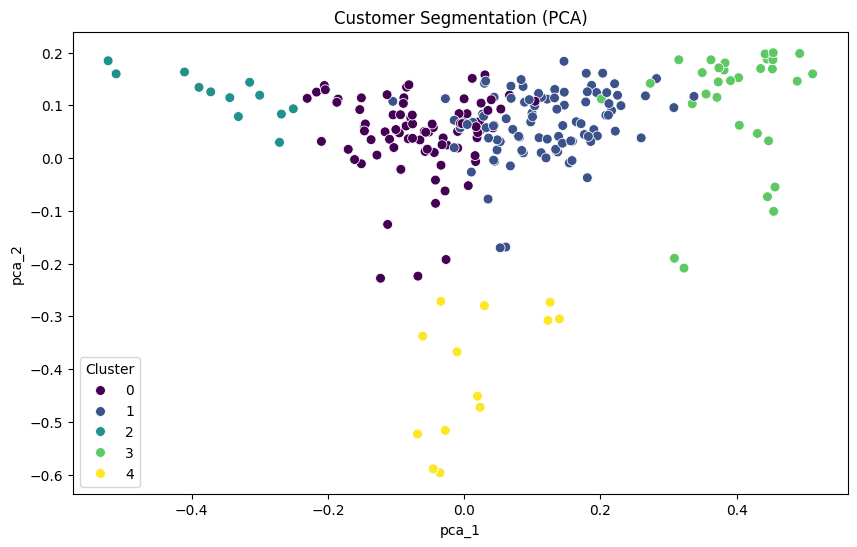

In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
df = pd.read_csv('youtube_comments.csv').dropna()

# Clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(embeddings)

# PCA Visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
df['pca_1'] = reduced[:, 0]
df['pca_2'] = reduced[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='Cluster', palette='viridis', s=50)
plt.title('Customer Segmentation (PCA)')
plt.show()

In [7]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
import os

# =========================================================
# เปลี่ยนมาใช้รุ่นเล็ก (1.5B) เพื่อแก้ปัญหา MEMORY เต็ม
# =========================================================
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"🔄 กำลังโหลดโมเดลรุ่นเล็ก {MODEL_NAME} (เพื่อความลื่น)...")

try:
    # Config แบบเบาสุดๆ
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
    )

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # โหลดโมเดล
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype="auto",
        device_map="auto",      # เลือกการ์ดจออัตโนมัติ
        quantization_config=bnb_config,
        trust_remote_code=True
    )

    # สร้าง Pipeline
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=1024,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        return_full_text=False
    )

    llm = HuggingFacePipeline(pipeline=pipe)
    chat_model = ChatHuggingFace(llm=llm, tokenizer=tokenizer)

    print(f"✅ โหลดโมเดลสำเร็จ! พร้อมใช้งาน (VRAM Usage: Low)")

except Exception as e:
    print(f"❌ Error: {e}")
    chat_model = None

# =========================================================
# ฟังก์ชันวิเคราะห์
# =========================================================

def dataframe_to_markdown(df):
    markdown = f"| {' | '.join(df.columns)} |\n"
    markdown += f"| {' | '.join(['---' for _ in df.columns])} |\n"
    for _, row in df.iterrows():
        markdown += f"| {' | '.join(str(cell).replace('\n', ' ') for cell in row)} |\n"
    return markdown

def analyze_persona(segment_df):
    if chat_model is None: return "โมเดลไม่พร้อม"

    # ลดจำนวนตัวอย่างลงเหลือ 10 เพื่อความเร็ว
    sample = segment_df[['Author', 'Comment Text']].sample(min(10, len(segment_df)))
    table = dataframe_to_markdown(sample)

    prompt = f"""
    วิเคราะห์ Persona ของกลุ่มนี้จากคอมเมนต์:
    {table}

    สรุป 3 ข้อ (ภาษาไทย):
    1. ชื่อกลุ่ม
    2. นิสัย/ความชอบ
    3. อารมณ์
    """

    try:
        response = chat_model.invoke(prompt)
        return response.content
    except Exception as e:
        return f"Error: {e}"

# =========================================================
# รันวิเคราะห์
# =========================================================

if 'df' in locals() and 'Cluster' in df.columns:
    clusters = sorted(df['Cluster'].unique())
    print("🚀 เริ่มวิเคราะห์...")

    for c in clusters:
        print(f"\n🔹 กลุ่มที่ {c}")
        segment = df[df['Cluster'] == c]
        if len(segment) > 0:
            result = analyze_persona(segment)
            print(result)
        else:
            print("- ไม่มีข้อมูล -")
else:
    print("⚠️ กรุณารัน Cell ก่อนหน้าเพื่อทำ Clustering")

🔄 กำลังโหลดโมเดลรุ่นเล็ก Qwen/Qwen2.5-1.5B-Instruct (เพื่อความลื่น)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

c:\Users\LENOVO\miniforge3\envs\rag-project\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--Qwen--Qwen2.5-1.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Device set to use cuda:0


✅ โหลดโมเดลสำเร็จ! พร้อมใช้งาน (VRAM Usage: Low)
🚀 เริ่มวิเคราะห์...

🔹 กลุ่มที่ 0
### สรุปPersona:

#### 1. ชื่อกลุ่ม
**Persona**: มีผู้เขียนทั้งหมด 8 คน และผู้เขียนที่ไม่มีโปรไฟล์เป็นคนร่วมกัน ซึ่งอาจหมายถึงกลุ่มของผู้เข้าร่วมการสนทนากับผู้เขียน

#### 2. นิสัย/ความชอบ
- **@RTG-t4t**: ใช้คำพูด "Я русский" เพื่อแสดงภาษาของตน แสดงให้เห็นว่าเป็นผู้ที่ต้องการความยุติธรรมและความเป็นจริงในภาษา
- **@1jertix**: ใช้คำพูด "yaa" แสดงความรู้สึกที่ค่อนข้างบังเอิญหรือพอใจ
- **@randomperson869**: ใช้คำพูด "mo" แสดงความสบายใจและคลายเครียด
- **@x4_vy**: ใช้คำพูด "fax" แสดงความรู้สึกที่เบื้องต้นหรือเริ่มต้น
- **@ChaoticTM**: ใช้คำพูด "xddddd" แสดงความรู้สึกที่ค่อนข้างพอใจหรือประทับใจ
- **@Vibe5114**: ใช้คำพูด ":D" แสดงความยุติธรรมและความเป็นจริงใน表情อันตราย
- **@ItzYanderGD**: ใช้คำพูด "Yo" แสดงความกระตือรือร้นในการทำอะไรบางอย่าง
- **@blueridgeocean**: ใช้คำพูด "10.4 boss" แสดงความภาคภูมิใจหรือเกียรติ
- **@Determined_6**: ใช้คำพูด "d:" แสดงความยุติธรรมและความเป็นจริงในภาษา

#### 3. อารมณ์
- ผู้เขียนทุกค